In [60]:
import numpy as np
import trimesh
from shapely.geometry import LineString

%pylab inline
%config InlineBackend.figure_format = 'svg'

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [61]:
mesh = trimesh.load_mesh("cone.stl")

In [62]:
print(mesh.bounds)  # [[xmin, ymin, zmin], [xmax, ymax, zmax]]

[[-0.025 -0.025  0.   ]
 [ 0.025  0.025  0.05 ]]


C:\Users\ChenYi\AppData\Local\Temp\ipykernel_11336\3961047346.py:2: DeprecationWarning: DEPRECATED: replace `path.to_planar`->`path.to_2D), removal 1/1/2026
  slice_2D, to_3D = slice.to_planar()


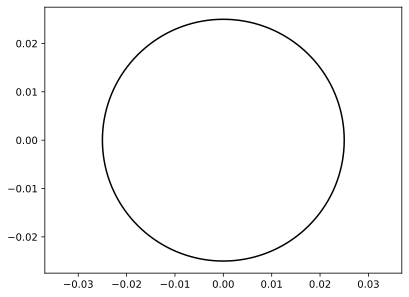

In [66]:
slice = mesh.section(plane_origin=[0, 0, 0.0], plane_normal=[0, 0, 1])
slice_2D, to_3D = slice.to_planar()
slice_2D.show()  # Displays the cross-section as a 2D shape

C:\Users\ChenYi\AppData\Local\Temp\ipykernel_11336\2291160741.py:9: DeprecationWarning: DEPRECATED: replace `path.to_planar`->`path.to_2D), removal 1/1/2026
  first_2D, _ = first_slice.to_planar()
C:\Users\ChenYi\AppData\Local\Temp\ipykernel_11336\2291160741.py:16: DeprecationWarning: DEPRECATED: replace `path.to_planar`->`path.to_2D), removal 1/1/2026
  slice_2D, _ = slice.to_planar()


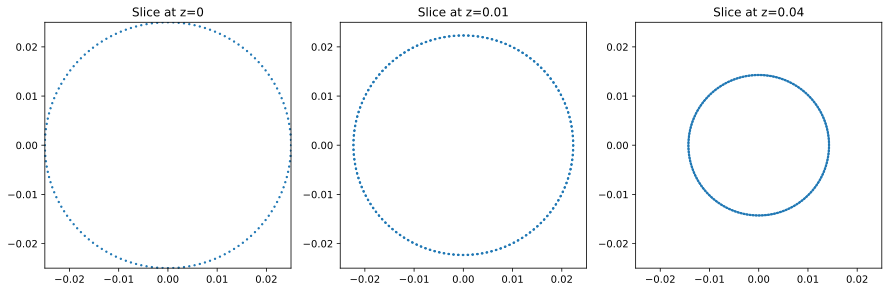

In [70]:
# Define different slice heights
slice_heights = [0, 0.01, 0.04]

# Create a figure
fig, axs = plt.subplots(1, len(slice_heights), figsize=(15, 5))

# Get initial bounds for consistent scaling
first_slice = mesh.section(plane_origin=[0, 0, slice_heights[0]], plane_normal=[0, 0, 1])
first_2D, _ = first_slice.to_planar()
x_min, y_min = first_2D.bounds[0]
x_max, y_max = first_2D.bounds[1]

# Iterate over each height and plot slices with fixed scaling
for i, height in enumerate(slice_heights):
    slice = mesh.section(plane_origin=[0, 0, height], plane_normal=[0, 0, 1])
    slice_2D, _ = slice.to_planar()
    
    # Convert to numpy array for plotting
    x, y = slice_2D.vertices[:, 0], slice_2D.vertices[:, 1]

    # Plot
    axs[i].scatter(x, y, s=2)
    axs[i].set_title(f"Slice at z={height}")
    
    # Set fixed axis limits based on the first slice
    axs[i].set_xlim(x_min, x_max)
    axs[i].set_ylim(y_min, y_max)
    axs[i].set_aspect('equal')  # Ensure aspect ratio remains consistent

plt.show()

In [73]:
print(mesh.volume)

5.494380719494435e-05
